**‘Quantum Practitioners’ webinar series**
# Getting started with Qiskit

Kifumi Numata, IBM Quantum, Mar 25, 2026 </br>
© 2026 International Business Machines Corporation

## Agenda

1. Single-qubit quantum circuit</br>
   - 1.1 Single-qubit circuit
   - 1.2 Statevector and Bloch sphere</br>
   - 1.3 Typical single-qubit gates</br>
   - 1.4 Sampler</br>
   - Exercise 1 </br>
   - 1.5 Estimator </br>
2. Multi-qubit quantum circuit</br>
   - 2.1 Two-qubit circuit</br>
   - 2.2 Typical two-qubit gates</br>
   - 2.3 Bell state</br>
3. Run on a real quantum device</br>
   - 3.1 Preparation for execution on IBM Quantum</br>
   - 3.2 Run with specified device</br>
4. Qiskit Patterns
   - 4.1 Map the problem to a quantum-native format
   - 4.2 Optimize the circuits
   - 4.3 Execute using a quantum primitive function
   - 4.4 Postprocess the results
   - Exercise 2</br>
5. (Optional) Parameterized circuit</br>
   - 5.1 Sampler</br>
   - 5.2 Estimator</br>
   - 5.3 Multiple parameters</br>
   - Exercise 3

If you are using Google Colab, please remove the '#' from the cell and execute it.    

In [1]:
#!pip install 'qiskit[visualization]' qiskit-ibm-runtime qiskit-aer

## 1. Single-qubit quantum circuit
### 1.1 Single-qubit circuit

Let's start from a single-qubit quantum circuit. You can run the cell by "Shift" + "Enter".

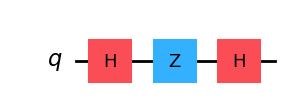

In [1]:
from qiskit import QuantumCircuit
# Preparer single-qubit quantum circuit
qc_z = QuantumCircuit(1)

# Operate single-qubit quantum gate
qc_z.h(0)
qc_z.z(0)
qc_z.h(0)

# Show the circuit
qc_z.draw('mpl')

### 1.2 Statevector and Bloch sphere
Next, we will simulate the above circuit using Statevector simulator. We can also show it on the Bloch sphere.

Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


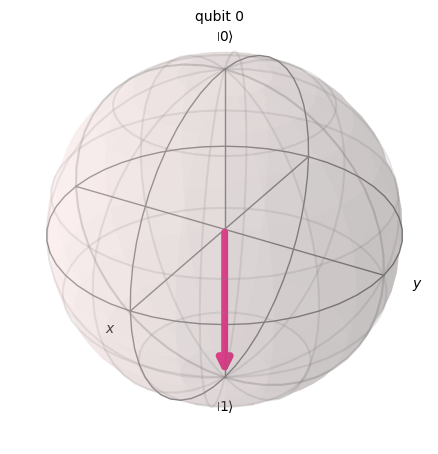

In [2]:
from qiskit.quantum_info import Statevector
sv = Statevector(qc_z)
print(sv)

from qiskit.visualization import plot_bloch_multivector
plot_bloch_multivector(sv)

### 1.3 Typical single-qubit gates
Let's try different gates. Please remove the '#' and try some of them.

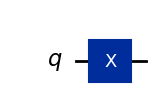

In [3]:
import numpy as np

qc = QuantumCircuit(1)

# Pauli gates
qc.x(0)
# qc.y(0)
# qc.z(0)

# Hadamard gate
# qc.h(0)

# Rotation gates - specify the rotation angle and qubit number
# qc.rx(np.pi, 0)
# qc.ry(np.pi, 0)
# qc.rz(np.pi, 0)

# Phase gates
# qc.p(np.pi, 0)

# draw the circuit
qc.draw(output="mpl")

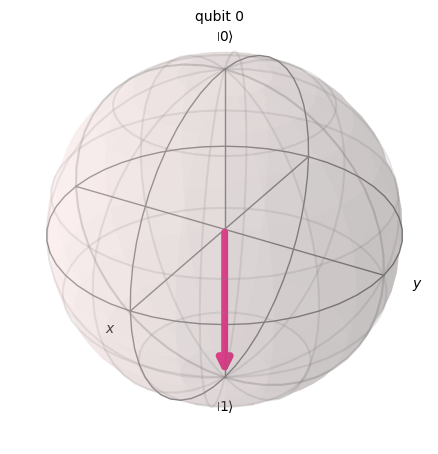

In [4]:
# Draw a Bloch sphere
plot_bloch_multivector(Statevector(qc))

For other single-qubit gates, please refer here: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit#methods-to-add-standard-instructions

### 1.4 Sampler

[Qiskit Primitive](https://quantum.cloud.ibm.com/docs/en/guides/primitives) Sampler's core task is sampling the output from the execution of a quantum circuit. Before performing on an actual quantum device, let's try using the simulator version, [StatevectorSampler](https://quantum.cloud.ibm.com/docs/en/guides/simulate-with-qiskit-sdk-primitives#use-the-reference-sampler).

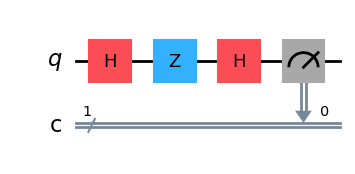

In [5]:
# Create the circuit with one qubit register and one classical register
qc_z = QuantumCircuit(1, 1)

# Operate quantum gates
qc_z.h(0)
qc_z.z(0)
qc_z.h(0)

# Measurement
qc_z.measure(0, 0)

# Show the circuit
qc_z.draw('mpl')

In [6]:
# Sampler simulator
from qiskit.primitives import StatevectorSampler
sampler_sim = StatevectorSampler()

# Execute it
job = sampler_sim.run([qc_z]) # defoult shot number is 1024

In [7]:
# Result
results = job.result()
counts = results[0].data.c.get_counts()
print(counts)

{'1': 1024}


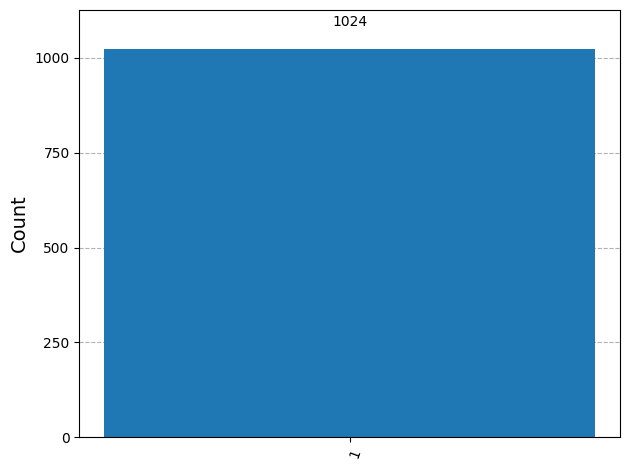

In [8]:
# Plot the result histogram
from qiskit.visualization import plot_histogram
plot_histogram(counts)

We can execute two circuits together.

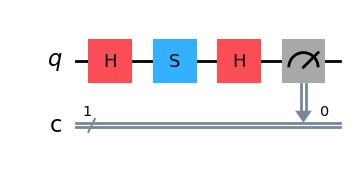

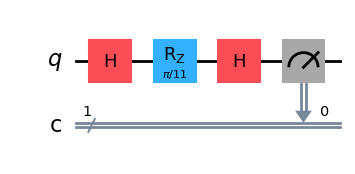

In [9]:
# The first circuit
qc_s = QuantumCircuit(1, 1)
qc_s.h(0)
qc_s.s(0)
qc_s.h(0)
qc_s.measure(0, 0)

# The second circuit
qc_rz = QuantumCircuit(1, 1)
qc_rz.h(0)
qc_rz.rz(np.pi/11, 0)
qc_rz.h(0)
qc_rz.measure(0, 0)

# Show the circuits.
display(qc_s.draw('mpl'))
display(qc_rz.draw('mpl'))

In [10]:
# Execution
job = sampler_sim.run([qc_s, qc_rz])
results = job.result()

In [11]:
# Show the counts
counts_all = [res.data.c.get_counts() for res in results]
print(counts_all[0], counts_all[1])

{'0': 538, '1': 486} {'0': 998, '1': 26}


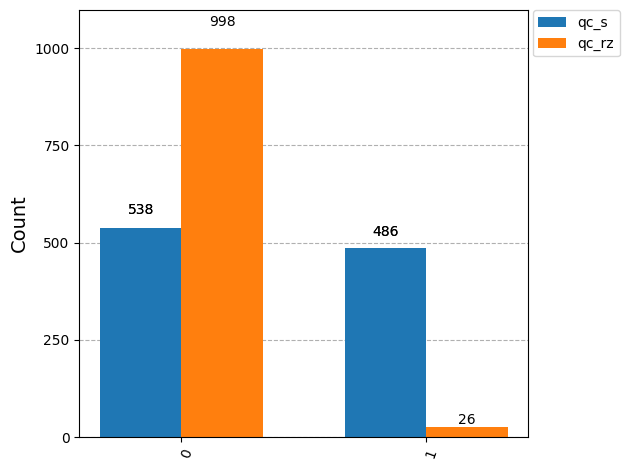

In [12]:
# Plot the result histgram
plot_histogram(counts_all, legend=['qc_s', 'qc_rz'])

<div class="alert alert-success">
    <h3>Exercise 1.</h3>
    <p>
    Build a same structured quantum circuit as above but using `p` gate between the hadamard gates with an angle of your choice. Simulate the circuit using the sampler and plot the result.</p>
    </p>
</div>

Reference: Phase gate([p gate](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit#qiskit.circuit.QuantumCircuit.p))

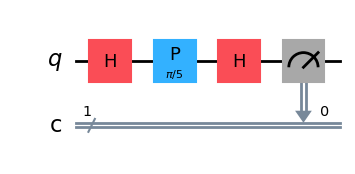

In [13]:
## your code goes here

myqc = QuantumCircuit(1, 1)
myqc.h(0)
myqc.p(np.pi/5, 0)
myqc.h(0)
myqc.measure(0, 0)
myqc.draw('mpl')

In [14]:
# Execution
job = sampler_sim.run([myqc])
counts = job.result()[0].data.c.get_counts()
print(counts)

{'0': 932, '1': 92}


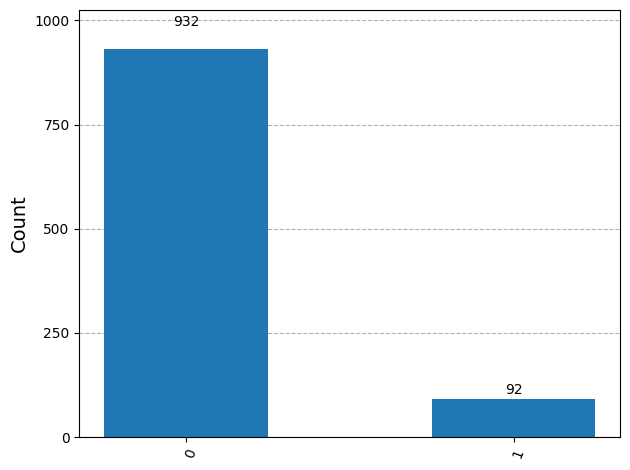

In [15]:
# Plot the result histogram
plot_histogram(counts)

### 1.5 Estimator
The [Estimator primitive](https://quantum.cloud.ibm.com/docs/en/guides/primitives#estimator) computes the expectation values for the observables with respect to states prepared by quantum circuits. 

In quantum mechanics, observables correspond to measurable physical properties. For example, when considering a spin system, we might be interested in the system's energy or magnetization. In quantum computers, these physical quantities are represented as observables expressed by Pauli operators, and we can calculate their expectation values by the measurement. Even outside of quantum mechanics, cost functions in optimization problems are expressed using Pauli operators, and we can get their expectation values.

In Qiskit, using Estimator primitive, we can get the expectation value of these observables, and 
[StatevectorEstimator](https://quantum.cloud.ibm.com/docs/en/guides/simulate-with-qiskit-sdk-primitives#use-the-reference-estimator) is the simulator version of estimator.

In [16]:
from qiskit.primitives import StatevectorEstimator
estimator_sim = StatevectorEstimator()

**Note**：Estimator does not take circuits with measurements.

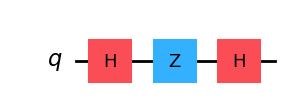

In [17]:
# Remove the measurement from above circuit. 
qc_z.remove_final_measurements()
qc_z.draw('mpl')

In [18]:
# Define the observable
from qiskit.quantum_info import Pauli, SparsePauliOp

# We can use both as the same meaning
observables = [Pauli('Z')]
# observables = [SparsePauliOp(['Z'], [1])]
print(observables)

[Pauli('Z')]


In [19]:
# Set pub(primitive unified block) 
pub = (qc_z, observables) #quantum circuit, observable

# Execution
job = estimator_sim.run([pub])

In [20]:
# Results
res = job.result()

# Show the expectation value 
expvals = res[0].data.evs
print(expvals)

[-1.]


## 2. Multi-qubit quantum ciruit

### 2.1 Two-qubit circuit
We can create a two-qubit quantum circuit with following code. We will apply an $H$ gate to each qubit.

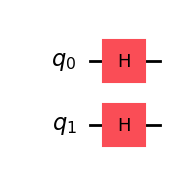

In [21]:
# Create the two qubits quantum circuit
qc = QuantumCircuit(2)

# Apply an H gate to qubit 0
qc.h(0)

# Apply an H gate to qubit 1
qc.h(1)

# Draw the circuit
qc.draw(output="mpl")

In [22]:
sv = Statevector(qc)
print(sv)

Statevector([0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j],
            dims=(2, 2))


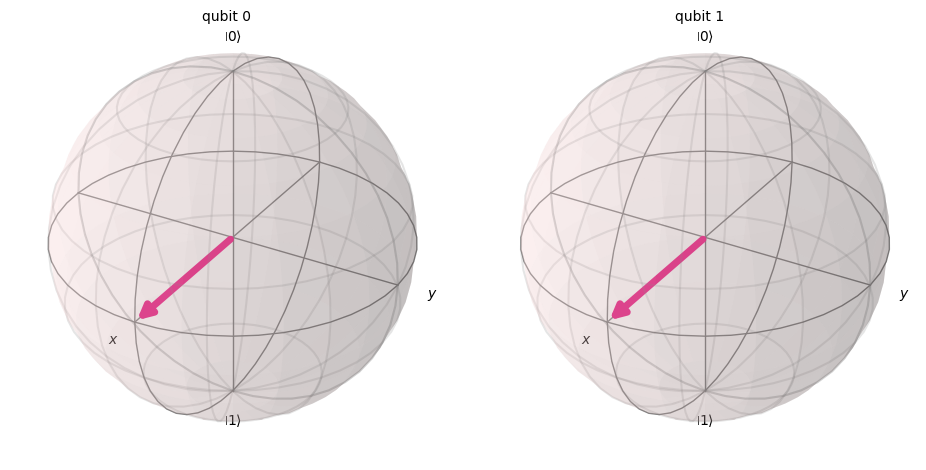

In [23]:
# Draw a Bloch sphere
plot_bloch_multivector(sv)

### 2.2 Typical two-qubit gates
Let's try various two-qubit gates.

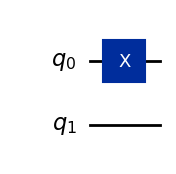

In [24]:
qc = QuantumCircuit(2)

qc.x(0)
# qc.x(1)

# Control-Pauli gates - Spcify control bit and target bit
# qc.cx(0, 1)
# qc.cy(0, 1)
# qc.cz(0, 1)

# Control-Rotation gates - Spcify rotation angle, control bit, and target bit
# qc.crx(np.pi, 0, 1)
# qc.cry(np.pi, 0, 1)
# qc.crz(np.pi, 0, 1)

# draw the circuit
qc.draw(output="mpl")

In [25]:
sv = Statevector(qc)
print(sv)

Statevector([0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))


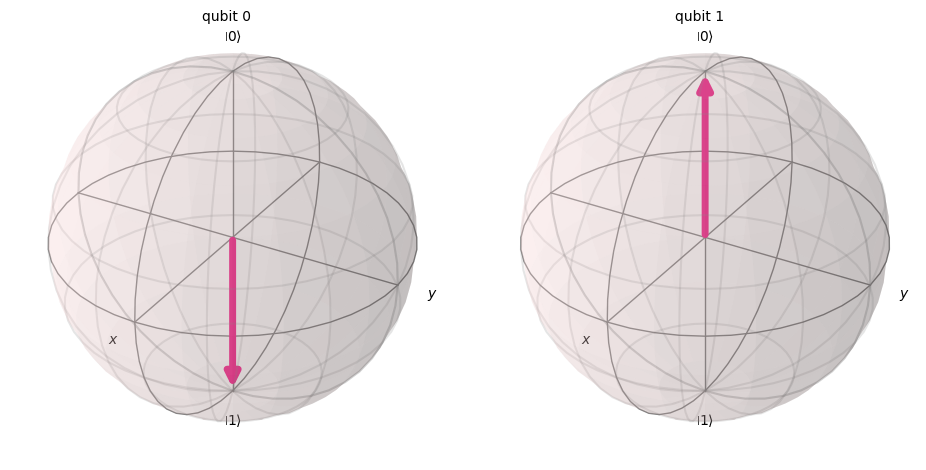

In [26]:
# Draw a Bloch sphere
plot_bloch_multivector(sv)

<div class="alert alert-info">
    <h3>Note: Qiskit bit ordering</h3>
    <p>
    Qiskit uses <strong>Little Endian</strong> notations for qubits and bits ordering, meaning <strong>qubit 0 is the rightmost bit</strong> in the bitstrings. Example: $|01\rangle$ means q0 is $|1\rangle$ and q1 is $|0\rangle$. Be careful because most of the literature in quantum computing use the Big Endian notation (qubit 0 is the leftmost bit).
    </p>
</div>

### 2.3 Bell state 

Let's create Bell's circuit using two-qubit circuit.

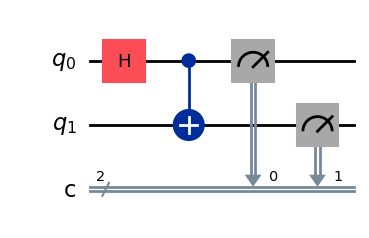

In [27]:
# Create a circuit with two qubit register and two classical register
qc_ent = QuantumCircuit(2, 2)

qc_ent.h(0)
qc_ent.cx(0, 1)

qc_ent.measure(range(2), range(2))

qc_ent.draw('mpl')

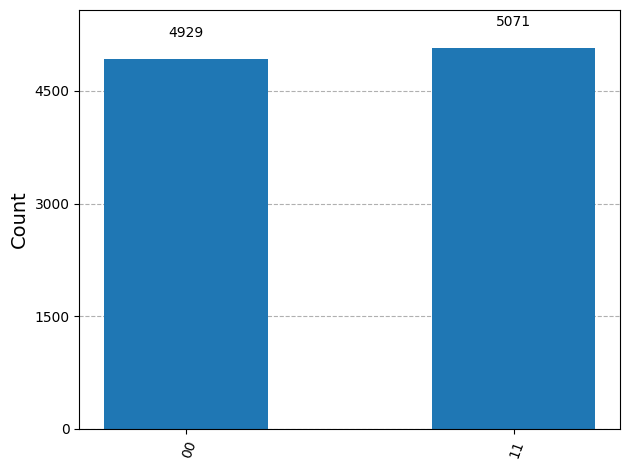

In [28]:
# Sampler simulator
sampler_sim = StatevectorSampler()

# Execution
job = sampler_sim.run([qc_ent], shots=10000)

# Plot the count result
counts_ent = job.result()[0].data.c.get_counts()
plot_histogram(counts_ent)

## 3. Run on a real quantum device

### 3.1 Preparation for execution on IBM Quantum

To experiment with a real quantum computer, enter the API key and CRN in the code of the following cell as follows:

1. Sign in to https://quantum.cloud.ibm.com/ and click "Create +" next to "API key" on the left.

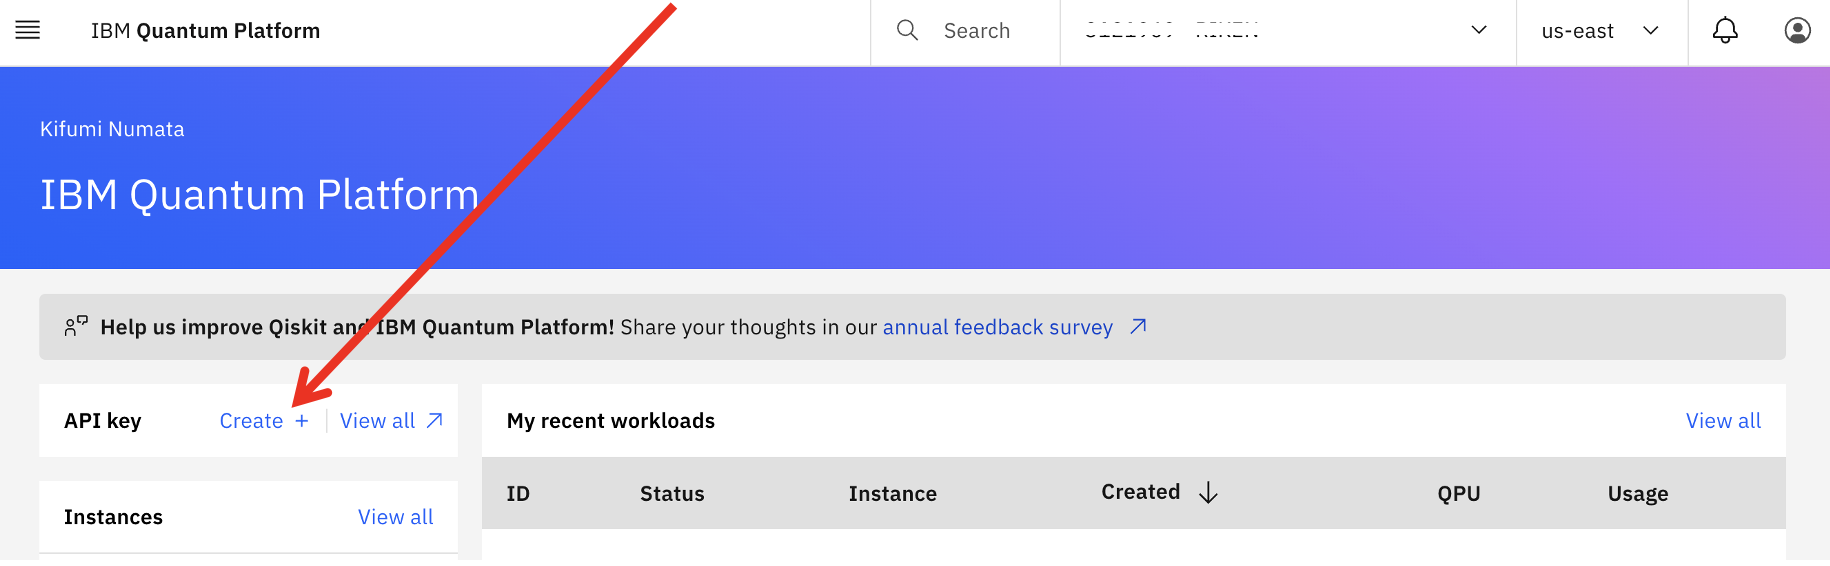

2. Enter the name of your API key (e.g., my API) and click "Create".
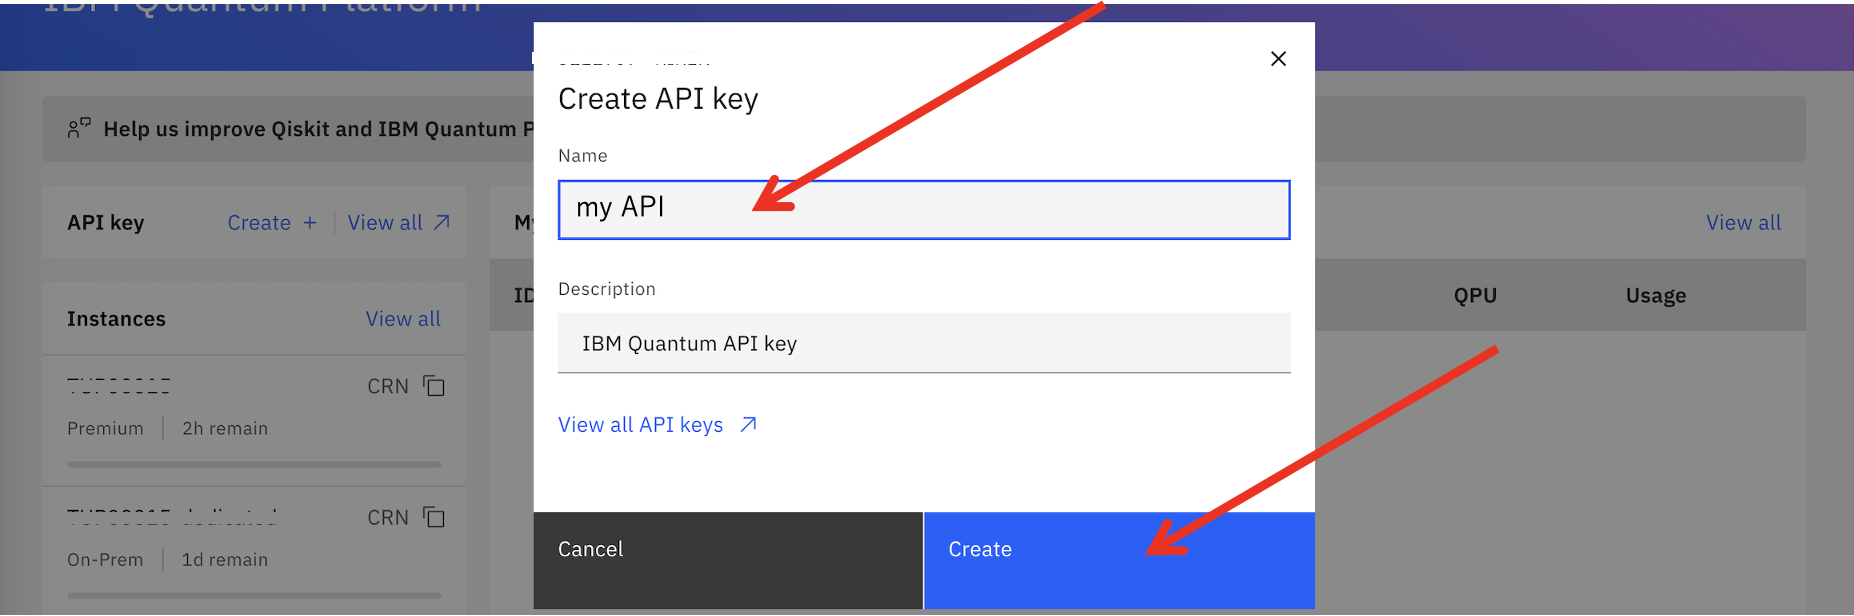

3. Click "Download" to save the "apikey.json" file.
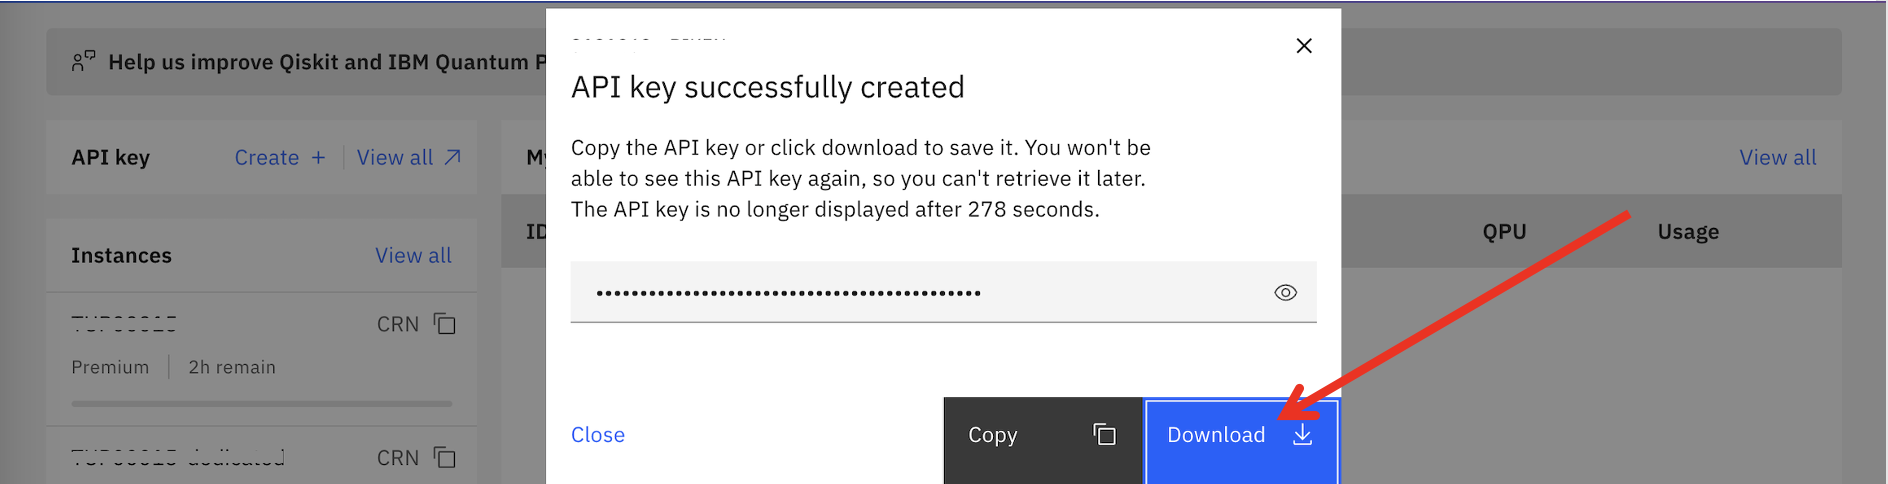

4. Copy the apikey from the "apikey.json" file you saved, and overwrite `deleteThisAndPasteYourAPIKeyHere` in the next cell.
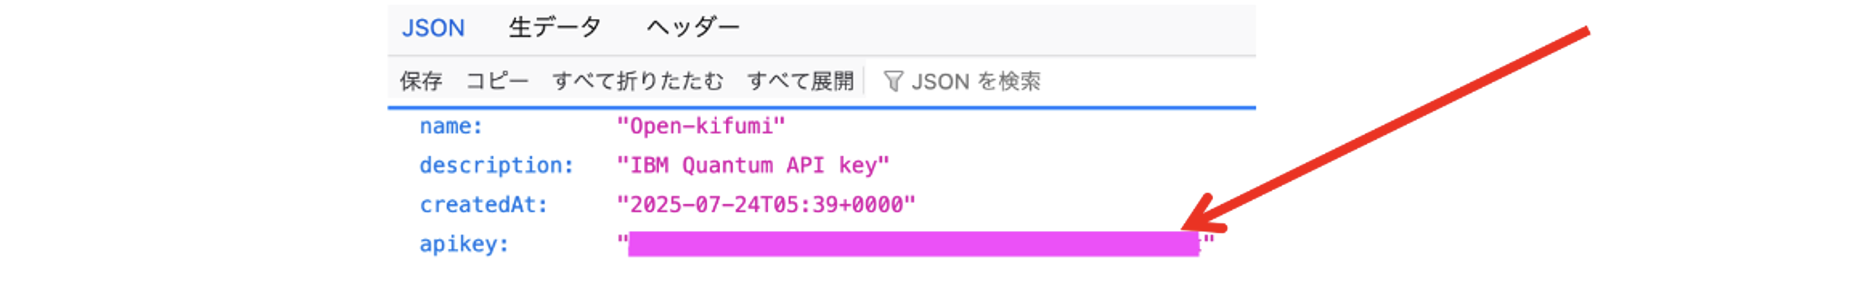

5. Copy the CRN, and overwrite `deleteThisAndPasteYourCRNHere` in the next cell.
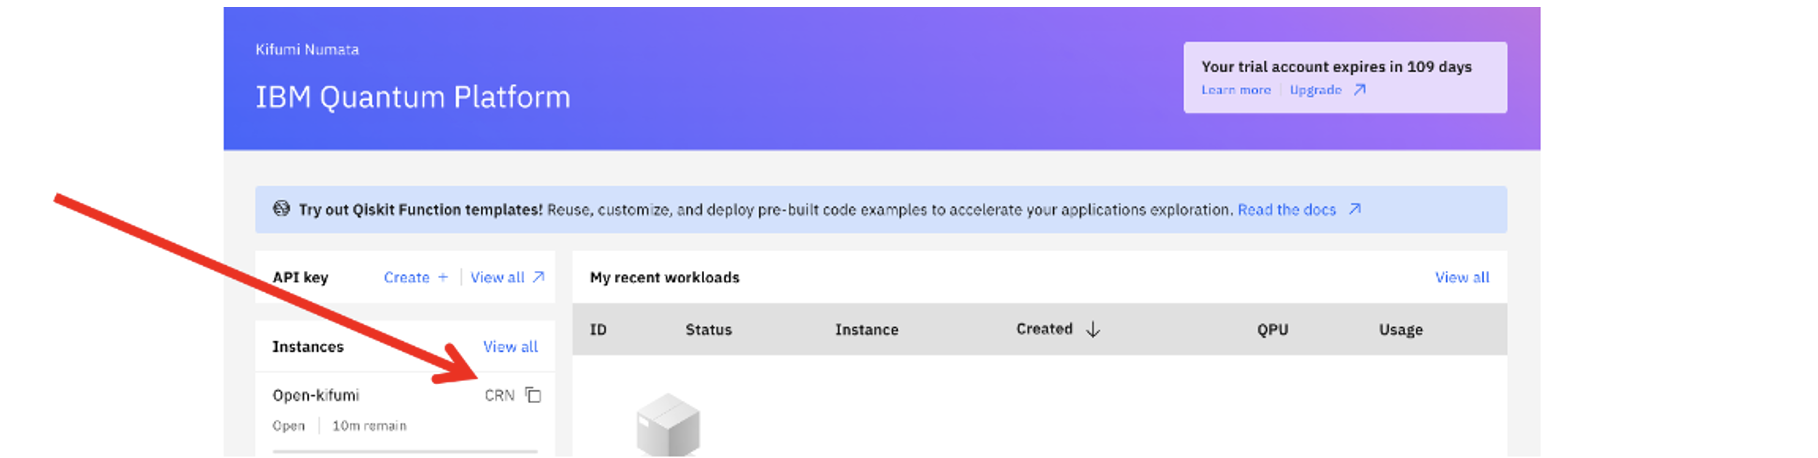

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

your_api_key = "deleteThisAndPasteYourAPIKeyHere"
your_crn = "deleteThisAndPasteYourCRNHere"

service = QiskitRuntimeService.save_account(
    channel="ibm_cloud",
    token=your_api_key,
    instance=your_crn,
    set_as_default=True,
    overwrite=True,
    name = "open" #please add your service name here
    #name = "ntu"
)

In [29]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(name = "open") 
service.backends()

[<IBMBackend('ibm_fez')>,
 <IBMBackend('ibm_marrakesh')>,
 <IBMBackend('ibm_kingston')>,
 <IBMBackend('ibm_torino')>]

### 3.2 Run with specified device

In [30]:
# You can specify the backend device
backend = service.backend('ibm_fez')

In [31]:
# You can also select the least busy backend.
backend = service.least_busy(operational=True)
print("The least busy backend is: ", backend)

The least busy backend is:  <IBMBackend('ibm_fez')>


Different devices may have different coupling maps. And, different quantum computers may have different native gates (gates the hardware can execute). Please refer Compute resources here: https://quantum.cloud.ibm.com/computers

Transpiling the circuit is to compile the circuit optimized for execution on a real machine backend. For more on transpilation, see this [documentation](https://quantum.cloud.ibm.com/docs/en/api/qiskit/transpiler).

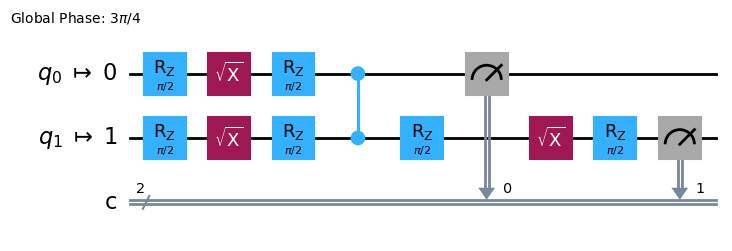

In [32]:
# Transpiles the circuit into a format optimized for execution on the real hardware
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc_ent)
isa_circuit.draw("mpl", idle_wires=False)

By transpiling the circuit, it was converted to a circuit using the native basis gates of the device. 

In [33]:
# Execution with sampler
from qiskit_ibm_runtime import SamplerV2 as Sampler
sampler = Sampler(backend)
job = sampler.run([isa_circuit]) # default shot number is 4096

print("job id:", job.job_id()) # show job_id in case of long queue time 

job id: d70u88s69uic73ckq4vg


In [34]:
job = service.job(job.job_id())
#job = service.job("d70u88s69uic73ckq4vg") #update to your job id shown above
job.status() # check the job status

'RUNNING'

You can also check the job status from your IBM Quantum Platform：https://quantum.cloud.ibm.com/workloads?user=me

In [35]:
# If the Notebook session got disconnected you can also check your job statuse by running the following code
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(name="open")
job = service.job('d70u88s69uic73ckq4vg') # Input your job-id between the quotations
job.status()

'DONE'

If the above cell displays 'DONE' as a result of execution, the execution on the real device is complete, so execute the following cell to check the result.

In [36]:
# Execute after 'DONE' has been appeared
result = job.result()
print(result[0].data.c.get_counts())

{'11': 1890, '00': 2003, '01': 94, '10': 109}


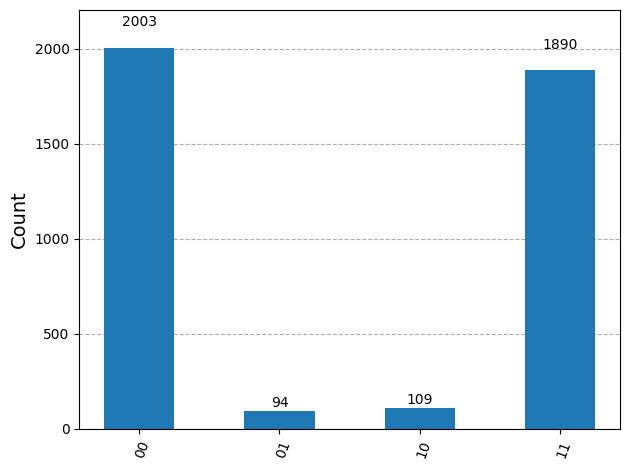

In [37]:
plot_histogram(result[0].data.c.get_counts())

## 4. Qiskit Patterns
Let's create a GHZ state and run it on a real quantum computer;

$$\frac{1}{\sqrt{2}}|000\rangle + \frac{1}{\sqrt{2}}|111\rangle$$

Now, we will follow 4 steps of Qiskit Patterns.

    1. Map the problem to a quantum-native format
    2. Optimize the circuits
    3. Execute using a quantum primitive function
    4. Postprocess the results

### 4.1 Map the problem to a quantum-native format

In a quantum program, quantum circuits are the native format in which to represent quantum instructions. When creating a circuit, you'll usually create a new QuantumCircuit object, then add instructions to it in sequence.

The following code cell creates a circuit that produces a GHZ state, which is a specific three-qubit entangled state.

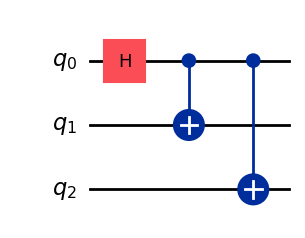

In [38]:
# Create a GHZ state circuit

qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0,1)
qc.cx(0,2)
# Draw the circuit
qc.draw("mpl")

The following code cell creates six three-qubit Pauli operators: `ZZZ`, `ZZX`, `ZII`, `XXI`, `ZZI` and `III`.

In [39]:
# Set up six different observables.
from qiskit.quantum_info import SparsePauliOp
observables_labels = ["ZZZ", "ZZX", "ZII", "XXI", "ZZI", "III"]

observables = [SparsePauliOp(label) for label in observables_labels]
print(observables)

[SparsePauliOp(['ZZZ'],
              coeffs=[1.+0.j]), SparsePauliOp(['ZZX'],
              coeffs=[1.+0.j]), SparsePauliOp(['ZII'],
              coeffs=[1.+0.j]), SparsePauliOp(['XXI'],
              coeffs=[1.+0.j]), SparsePauliOp(['ZZI'],
              coeffs=[1.+0.j]), SparsePauliOp(['III'],
              coeffs=[1.+0.j])]


### 4.2 Optimize the circuits
Qiskit converts abstract circuits to QISA (Quantum Instruction Set Architecture) circuits that respect the constraints of the target hardware and optimizes circuit performance.  Before the optimization, we will specify the target hardware.

In [40]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(name = "open")
backend = service.least_busy(
    simulator=False, operational=True, min_num_qubits=100
)
print(f"Using backend: {backend.name}")

Using backend: ibm_fez


Transpiling the circuit is to compile the circuit optimized for execution on a real machine backend.

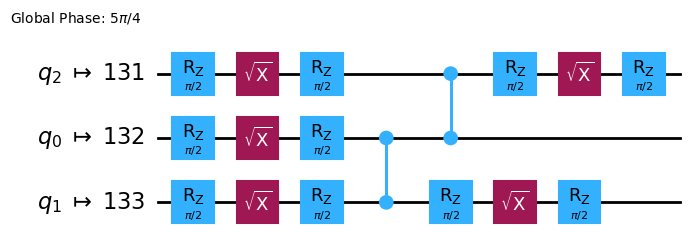

In [41]:
# Transpile the circuit into basis gates executable on the hardware
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

isa_circuit.draw("mpl", idle_wires=False)

By transpiling the circuit, it was converted to a circuit using the native basis gates of the device.

### 4.3 Execute using a quantum primitive function

Now, we will run the target circuit on the real device. Submit a job using the Estimator primitive.


In [42]:
# Construct the Estimator instance.
from qiskit_ibm_runtime import EstimatorV2 as Estimator
estimator = Estimator(mode=backend)

# Map the observables to physical qubit
mapped_observables = [
    observable.apply_layout(isa_circuit.layout) for observable in observables
]

# One pub, with one circuit to run against six different observables.
job = estimator.run([(isa_circuit, mapped_observables)])

print("job id:", job.job_id()) # show job_id in case of long queue time 

job id: d70u8iatnsts73eunlig


In [43]:
job = service.job(job.job_id())
#job = service.job("d70u8iatnsts73eunlig")
job.status() # check the job status

'RUNNING'

In [45]:
# If the Notebook session got disconnected you can also check your job statuse by running the following code
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(name="open")
job = service.job('d70u8iatnsts73eunlig') # Input your job-id between the quotations
job.status()

'DONE'

If the above cell displays 'DONE' as a result of execution, the execution on the real device is complete, so continue the following cell.

In [46]:
# This is the result from our single pub, which had six observables,
# so contains information on all six.
pub_result = job.result()[0]

**Alternative: run the example using a simulator**

When you run your quantum program on a real device, your workload must wait in a queue before it runs. To save time, you can instead use the following code to run this small workload on the [fake_provider](https://quantum.cloud.ibm.com/docs/api/qiskit-ibm-runtime/fake-provider) with the Qiskit Runtime local testing mode. Note that this is only possible for a small circuit. When you scale up, you will need to use a real device.

In [47]:
# Use the following code instead if you want to run on a simulator:

from qiskit_ibm_runtime.fake_provider import FakeBelemV2
backend = FakeBelemV2()
estimator = Estimator(backend)

# Convert to an ISA circuit and layout-mapped observables.

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)
mapped_observables = [
    observable.apply_layout(isa_circuit.layout) for observable in observables
]

job = estimator.run([(isa_circuit, mapped_observables)])
result = job.result()

# This is the result of the entire submission.  You submitted one Pub,
# so this contains one inner result (and some metadata of its own).

job_result = job.result()

# This is the result from our single pub, which had five observables,
# so contains information on all five.

pub_result = job.result()[0]

### 4.4 Postprocess the results
Finally, we must post-process our results to create outputs in the expected format like values or graphs.

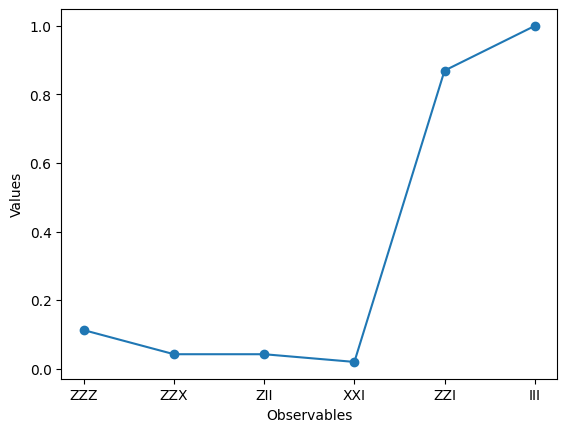

In [48]:
# Plot the result
from matplotlib import pyplot as plt
values = pub_result.data.evs
errors = pub_result.data.stds
# plotting graph
plt.plot(observables_labels, values, "-o")
plt.xlabel("Observables")
plt.ylabel("Values")
plt.show()

We see that the observables $ZZI$ and $III$ have an expectation value of 1, since $ZZI$ introduces two minus signs that cancel out, and $III$ acts as the identity, leaving the GHZ state unchanged. The rest of the observables have an expectation value of 0, since their $Z$ operators introduce an odd number of minus signs, or the $X$ operators flip a number of qubits that make the overlapping states orthogonal.

<div class="alert alert-success">
    <h3>Exercise 2.</h3>
    <p>
    Build the circuits that output the following quantum state and execute it using Sampler on FakeTorino. You should follow the Qiskit Patterns.

 $$\frac{1}{4}(|0000\rangle+|0001\rangle+|0010\rangle+|0011\rangle+ \dots+|1111\rangle)$$</p>
    </p>
</div>

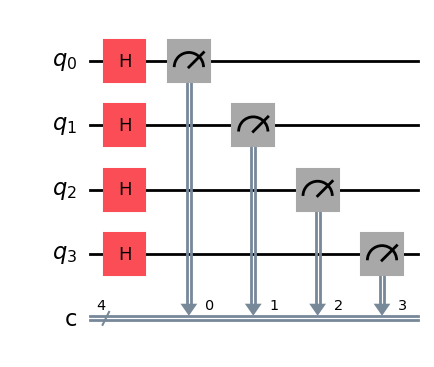

In [49]:
# Step 1. Map the problem to a quantum-native format
from qiskit import QuantumCircuit
qc = QuantumCircuit(4, 4)

for i in range(4):
    qc.h(i)
    qc.measure(i, i)

qc.draw("mpl")

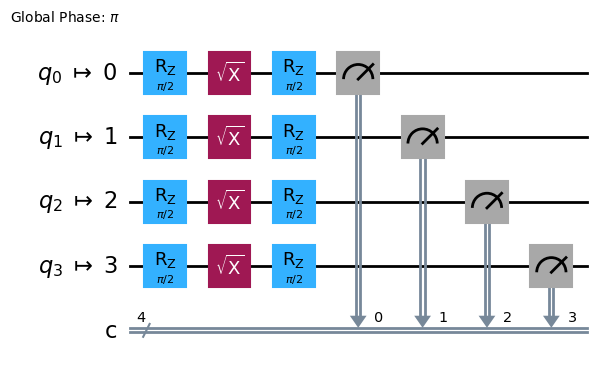

In [50]:
# Step 2. Optimize the circuits
from qiskit_ibm_runtime.fake_provider import FakeTorino
backend = FakeTorino()

# Transpiles the circuit into a format optimized for execution on the real hardware
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

isa_circuit.draw("mpl", idle_wires=False)

In [51]:
# Step 3. Execute using a quantum primitive function
from qiskit_ibm_runtime import SamplerV2 as Sampler
sampler = Sampler(backend)

job = sampler.run([isa_circuit])
result = job.result()

In [52]:
# Result
counts = result[0].data.c.get_counts()
print(counts)

{'0000': 70, '0110': 54, '1101': 76, '0011': 79, '1100': 58, '0101': 50, '1110': 65, '1010': 68, '0010': 65, '0100': 61, '0111': 57, '0001': 69, '1001': 72, '1111': 60, '1011': 59, '1000': 61}


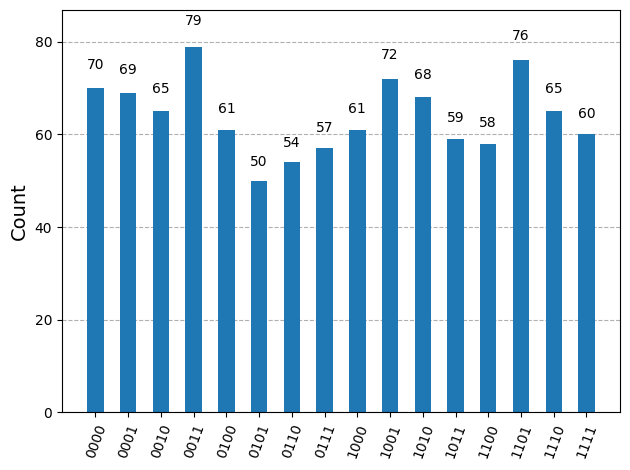

In [53]:
# Step 4. Postprocess the results
# Plot the result histogram
from qiskit.visualization import plot_histogram
plot_histogram(counts)

## Optional: 5. Parameterized circuit

We can build the parameterized quantum circuit, input data into the parameters, and then execute it.

### 5.1 Sampler

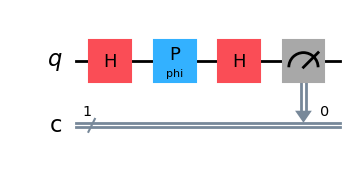

In [54]:
# Set the parameter
from qiskit.circuit import Parameter
phi = Parameter('phi')

# Create the circuit with parameter
qc_p = QuantumCircuit(1, 1)
qc_p.h(0)
qc_p.p(phi, 0)
qc_p.h(0)
qc_p.measure(0, 0)
qc_p.draw('mpl')

In [55]:
# Create 100 values to put into the parameters
num_angles = 100
angles_p = np.linspace(0, 2*np.pi, num_angles)

In [56]:
# Execute 100 circuits together using StatevectorSampler
pub = (qc_p, angles_p) #circuit, parameter values
sampler_sim = StatevectorSampler()
job = sampler_sim.run([pub])

In [57]:
# Result
results = job.result()

# Example: result of the third circuit
k = 3
print(results[0].data.c.get_counts(k))

{'0': 1015, '1': 9}


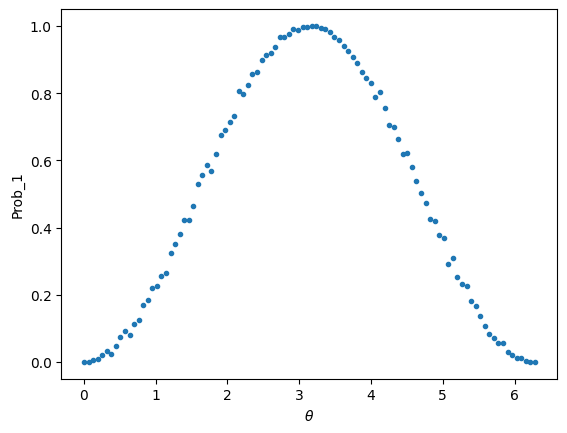

In [58]:
import matplotlib.pyplot as plt
# Show the result
prob1 = []

for k in range(num_angles):
    counts = results[0].data.c.get_counts(k)
    if '1' in counts:
        prob1.append(counts['1']/sum(counts.values()))
    else:
        prob1.append(0)

fig, ax = plt.subplots()
ax.plot(angles_p, prob1, '.')
ax.set_xlabel('$\\theta$')
ax.set_ylabel('Prob_1');

### 5.2 Estimator

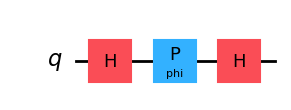

In [59]:
# Remove measurement from above circuit
qc_p.remove_final_measurements()
qc_p.draw('mpl')

In [60]:
# Define the circuit and observable
circuit = qc_p
observables = Pauli('Z')
parameter_vals = angles_p

# PUB
pub_p = (circuit, observables, parameter_vals) #circuit, observables, parameter values

# Execution
estimator_sim = StatevectorEstimator()
job = estimator_sim.run([pub_p])

In [61]:
# Result
results = job.result()

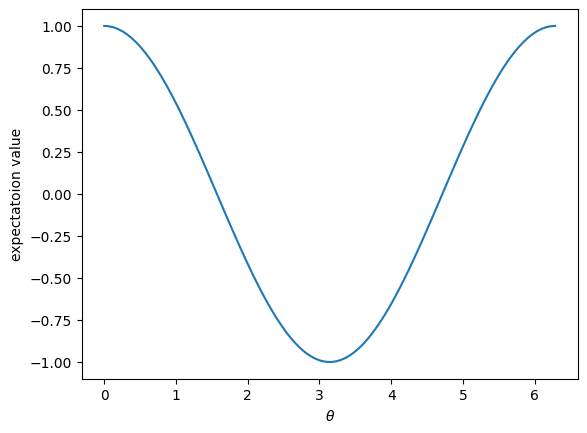

In [62]:
fig, ax = plt.subplots()
ax.plot(angles_p, results[0].data.evs)
ax.set_xlabel('$\\theta$')
ax.set_ylabel('expectatoion value');

### 5.3 Multipule parameters
- Reference: [u gate](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.UGate)

3


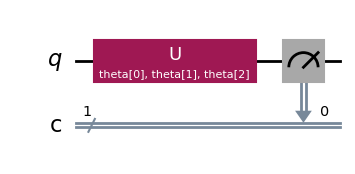

In [63]:
# Define multiple parameters 
from qiskit.circuit import ParameterVector
theta = ParameterVector('theta', 3)
print(len(theta))

qc_u = QuantumCircuit(1, 1)

# We can use both as the same meaning
#qc_u.u(theta[0], theta[1], theta[2], 0)
qc_u.u(*theta, 0)

qc_u.measure(0, 0)

qc_u.draw('mpl')

In [64]:
# Create four values for each of the three parameters.
angles_u = [[np.pi/k, np.pi/(k+3), np.pi/(k/2+2)] for k in range(3, 7)]
angles_u

[[1.0471975511965976, 0.5235987755982988, 0.8975979010256552],
 [0.7853981633974483, 0.4487989505128276, 0.7853981633974483],
 [0.6283185307179586, 0.39269908169872414, 0.6981317007977318],
 [0.5235987755982988, 0.3490658503988659, 0.6283185307179586]]

In [65]:
# Define PUB
pub = (qc_u, angles_u) # circuit, parameter value
# Execution
sampler_sim = StatevectorSampler()
job = sampler_sim.run([pub])
results = job.result()

In [66]:
# Obtain the count
counts_all = [results[0].data.c[k].get_counts() for k in range(len(angles_u))]
counts_all

[{'0': 778, '1': 246},
 {'0': 893, '1': 131},
 {'0': 918, '1': 106},
 {'0': 948, '1': 76}]

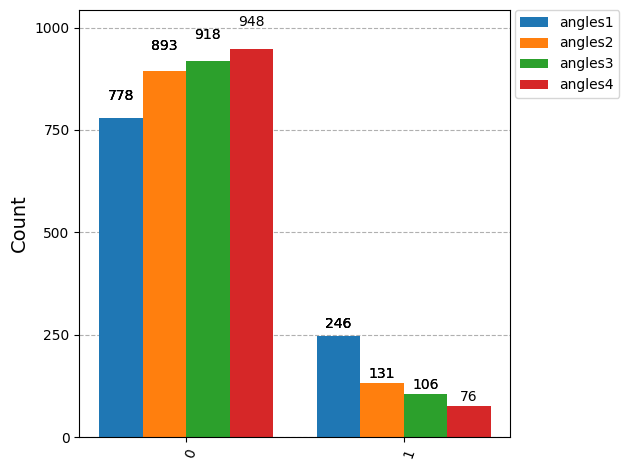

In [67]:
# Plot the result histogram
plot_histogram(counts_all, legend=['angles1', 'angles2', 'angles3', 'angles4'])

<div class="alert alert-success">
    <h3>Exercise 3.</h3>
    Obtain the expectation values of `Z` and `X` for `qc_u` with above `angles_u` using StatevectorEstimator.
    </p>
</div>

In [68]:
## Your code goes here
## Solution example
qc_u.remove_final_measurements()

circuit = qc_u
observables = [[SparsePauliOp(['Z'], [1])], [SparsePauliOp(['X'], [1])]]
#observables = [[Pauli('Z')], [Pauli('X')]]
parameter_values = angles_u

pub_u = (circuit, observables, parameter_values)

In [69]:
# Execution
job = estimator_sim.run([pub_u])

In [70]:
# Results
results = job.result()
expvals_all = results[0].data.evs

In [71]:
# Print the results
obs_names = ['Z', 'X']
for idx, obs in enumerate(obs_names):
    expvals = np.round(expvals_all[idx], 2)
    print('Expectation values of {} for the four cases: {}'.format(obs, expvals))

Expectation values of Z for the four cases: [0.5  0.71 0.81 0.87]
Expectation values of X for the four cases: [0.75 0.64 0.54 0.47]
